In [66]:
import torch
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import kagglehub
from kagglehub import KaggleDatasetAdapter

Dataset

In [67]:
df = pd.read_csv('/kaggle/input/datasets/burnoutminer/heights-and-weights-dataset/SOCR-HeightWeight.csv')
print(df.head())
print(df.shape)
print(df.columns)

   Index  Height(Inches)  Weight(Pounds)
0      1        65.78331        112.9925
1      2        71.51521        136.4873
2      3        69.39874        153.0269
3      4        68.21660        142.3354
4      5        67.78781        144.2971
(25000, 3)
Index(['Index', 'Height(Inches)', 'Weight(Pounds)'], dtype='object')


Convert Height unit from inches to cm

In [68]:
df['Height_cm'] = df['Height(Inches)'] * 2.54
print(df["Height_cm"])

0        167.089607
1        181.648633
2        176.272800
3        173.270164
4        172.181037
            ...    
24995    176.535461
24996    163.952580
24997    164.334317
24998    171.524117
24999    174.949129
Name: Height_cm, Length: 25000, dtype: float64


Defining Mu and Sigma as learnable parameters

In [69]:
mu = torch.tensor([170.0], requires_grad=True)
sigma = torch.tensor([10.0], requires_grad=True)

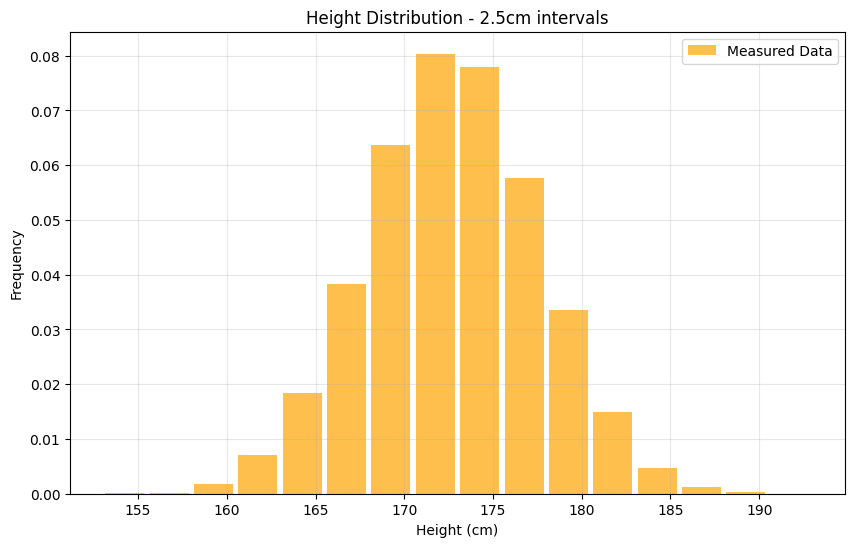

In [70]:
heights = df["Height_cm"]

minimum = np.floor(heights.min())
maximum = np.ceil(heights.max())

bins = np.arange(minimum, maximum + 2.5, 2.5)

counts, bin_edges = np.histogram(heights, bins=bins, density= True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.bar(bin_centers, counts,
        width=2.2,
        color='orange',
        alpha=0.7,
        label='Measured Data')
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.title('Height Distribution - 2.5cm intervals')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Creating Histogram with 2.5 cm intervals


In [71]:
f_tensor = torch.tensor(counts, dtype = torch.float32)
bin_centers_tensor = torch.tensor(bin_centers, dtype = torch.float32)

def calculate_SSR(mu, sigma):

    #Normal Gausian Distribution Formula
    g = (1 / (sigma * torch.sqrt(torch.tensor(2 * np.pi)))) * \
            torch.exp(-((bin_centers_tensor - mu) ** 2) / (2 * sigma ** 2))
    ssr = torch.sum((f_tensor - g)**2)
    return ssr

print(calculate_SSR(mu = mu, sigma = sigma))

    

tensor(0.0065, grad_fn=<SumBackward0>)


Optimizer

In [78]:
optimizer = optim.SGD([mu, sigma], lr=100)

best_loss = float('inf')
best_mu = None
best_sigma = None

for i in range(1000):
    optimizer.zero_grad()
    loss = calculate_SSR(mu, sigma)
    loss.backward()
    optimizer.step()
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_mu = mu.item()
        best_sigma = sigma.item()
    
    if i % 100 == 0:
        print(f"Iteration {i}: μ={mu.item():.2f}, σ={sigma.item():.2f}, SSR={loss.item():.6f}")

print(f"\nBest μ: {best_mu:.2f}")
print(f"Best σ: {best_sigma:.2f}")
print(f"Best SSR: {best_loss:.6f}")

Iteration 0: μ=172.71, σ=4.88, SSR=0.000001
Iteration 100: μ=172.71, σ=4.88, SSR=0.000001
Iteration 200: μ=172.71, σ=4.88, SSR=0.000001
Iteration 300: μ=172.71, σ=4.88, SSR=0.000001
Iteration 400: μ=172.71, σ=4.88, SSR=0.000001
Iteration 500: μ=172.71, σ=4.88, SSR=0.000001
Iteration 600: μ=172.71, σ=4.88, SSR=0.000001
Iteration 700: μ=172.71, σ=4.88, SSR=0.000001
Iteration 800: μ=172.71, σ=4.88, SSR=0.000001
Iteration 900: μ=172.71, σ=4.88, SSR=0.000001

Best μ: 172.71
Best σ: 4.88
Best SSR: 0.000001


Visually Identifying Residuals

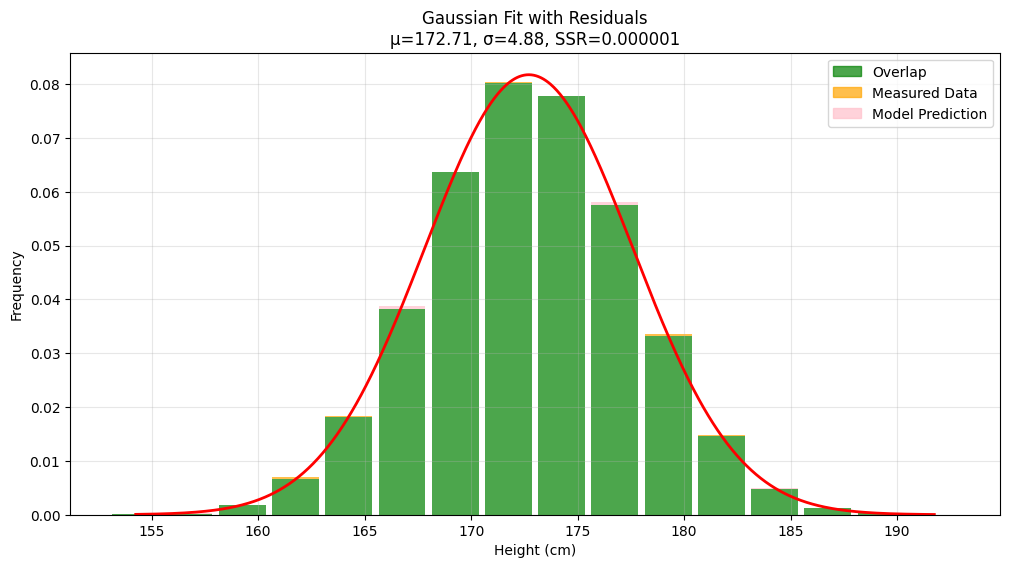


Final Results:
Best μ: 172.71 cm
Best σ: 4.88 cm
Best SSR: 0.00000099


In [79]:
# Cell 7 - Final Visualization with Residuals (just like Coursera!)
import numpy as np
import matplotlib.pyplot as plt

# Generate smooth pink curve using best mu and sigma
x = np.linspace(bin_centers.min(), bin_centers.max(), 1000)
g = (1 / (best_sigma * np.sqrt(2 * np.pi))) * \
    np.exp(-((x - best_mu) ** 2) / (2 * best_sigma ** 2))

# Calculate g at bin centers for residuals
g_at_bins = (1 / (best_sigma * np.sqrt(2 * np.pi))) * \
    np.exp(-((bin_centers - best_mu) ** 2) / (2 * best_sigma ** 2))

plt.figure(figsize=(12, 6))

# Plot each bar with colors like Coursera
for i in range(len(bin_centers)):
    f_val = counts[i]
    g_val = g_at_bins[i]
    
    overlap = min(f_val, g_val)
    
    # Green = overlap
    plt.bar(bin_centers[i], overlap, 
            width=2.2, color='green', alpha=0.7)
    
    # Orange = real data above overlap
    if f_val > overlap:
        plt.bar(bin_centers[i], f_val - overlap,
                bottom=overlap,
                width=2.2, color='orange', alpha=0.7)
    
    # Pink = model above overlap
    if g_val > overlap:
        plt.bar(bin_centers[i], g_val - overlap,
                bottom=overlap,
                width=2.2, color='pink', alpha=0.7)

# Plot smooth pink curve
plt.plot(x, g, color='red', linewidth=2, label='Model (Gaussian)')

# Labels
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.title(f'Gaussian Fit with Residuals\nμ={best_mu:.2f}, σ={best_sigma:.2f}, SSR={best_loss:.6f}')
plt.legend([
    plt.Rectangle((0,0),1,1, color='green', alpha=0.7),
    plt.Rectangle((0,0),1,1, color='orange', alpha=0.7),
    plt.Rectangle((0,0),1,1, color='pink', alpha=0.7),
], ['Overlap', 'Measured Data', 'Model Prediction'])
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nFinal Results:")
print(f"Best μ: {best_mu:.2f} cm")
print(f"Best σ: {best_sigma:.2f} cm")
print(f"Best SSR: {best_loss:.8f}")